# Landmark Preference: Open-Loop VR Comparison

Compares landmark preference distributions across 3 conditions per cortical layer.

- **Last Day**: Active VR (closed-loop)
- **Day 8**: Running replay (open-loop, animal moves freely)
- **Day 9**: Stationary replay (open-loop, animal immobilized)

**Workflow:**
1. Run `run_landmark_analysis()` for each session (HDF5 saved to TSeries folder)
2. Load results and compare landmark proportions across conditions per layer
3. Save figures to animal `output_dir` and `across_animals_OpenLoopVR_Analysis/`

In [5]:
import sys
sys.path.insert(0, r'C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation')
sys.path.insert(0, r'C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\3.LandmarkPreference')

import os
import glob
import traceback
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency

from LandmarkPreference_OpenLoopVR_Analysis import run_landmark_analysis
from helper import files as hfiles
from helper import TwoP
from helper.SpatialModulationIndexLayerSpecific import SpatialModulationIndexLayerSpecific as SMI_Layer

%matplotlib inline

rcParams['legend.fontsize'] = 16
rcParams['axes.labelsize']  = 16
rcParams['axes.titlesize']  = 18
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14

CONDITIONS  = ['LastDay', 'OpenLoop_Moving', 'OpenLoop_Stationary']
COND_LABELS = ['Last Day (Active VR)', 'Day 8 (Running replay)', 'Day 9 (Stationary replay)']
COND_COLORS = ['#2196F3', '#FF9800', '#E53935']

LAYER_NAMES = ['L2/3', 'L4', 'L5', 'L6']

LANDMARK_LABELS    = ['Q1 (37 cm)', 'Q2 (65 cm)', 'Q3 (93 cm)', 'Q4 (120 cm)']
LANDMARK_COLORS    = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

ACROSS_ANIMALS_DIR = r'D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis'
ANIMAL_COLORS = ['#9C27B0', '#009688', '#FF5722', '#607D8B']

print('Setup complete.')

Setup complete.


In [6]:
SESSIONS = [
    {
        'animal_id':           'JSY044',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250912_JSY_JSY044_SpatialModulation_Day7\TSeries-09122025-1334-001',
        # 'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250910_JSY_JSY044_SpatialModulation_Day5\TSeries-09102025-1340-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251122_JSY_JSY044_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251123_JSY_JSY044_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-001',
        'output_dir':          r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day7',
    },
    {
        'animal_id':           'JSY051',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251105_JSY_JSY051_SpMod_Day5\TSeries-11052025-1512-002',
        # 'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251104_JSY_JSY051_SpMod_Day4\TSeries-11042025-1418-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251106_JSY_JSY051_SpMO_OpenloopVR_moving\TSeries-11062025-1439-002',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251107_JSY_JSY051_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001',
        'output_dir':          r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day5',
    },
    {
        'animal_id':           'JSY052',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251015_JSY_JSY052_SpatialModulation_Day7\TSeries-10152025-1103-001',
        # 'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251013_JSY_JSY052_SpatialModulation_Day5\TSeries-10132025-1236-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251122_JSY_JSY052_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251123_JSY_JSY052_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-002',
        'output_dir':          r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day7',
    },
    {
        'animal_id':           'JSY054',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251105_JSY_JSY054_SpMod_Day7\TSeries-11052025-1512-001',
        # 'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251103_JSY_JSY054_SpMod_Day5\TSeries-11032025-1715-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251106_JSY_JSY054_SpMO_OpenloopVR_moving\TSeries-11062025-1439-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251107_JSY_JSY054_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001',
        'output_dir':          r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day7',
    },
    {
        'animal_id':           'JSY055',
        'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251211_JSY_JSY055_SpatialModulation_Day7\TSeries-12112025-1631-001',
        # 'LastDay':             r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251209_JSY_JSY055_SpatialModualtion_Day5\TSeries-12092025-2000-001',
        'OpenLoop_Moving':     r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251212_JSY_JSY055_SpatialModulation_OpenLoopVR_Moving\TSeries-12122025-1421-001',
        'OpenLoop_Stationary': r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251213_JSY_JSY055_SpatialModulation_OpenLoopVR_Stationary\TSeries-12132025-1711-001',
        'output_dir':          r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day7',
    },
]

print(f'Sessions: {[s["animal_id"] for s in SESSIONS]}')

Sessions: ['JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']


In [7]:
INCLUDE_ANIMALS = [
    # 'JSY044',
    # 'JSY051',
    # 'JSY052',
    # 'JSY054',
    'JSY055',
]


# LANDMARK_POSITIONS = [37, 65, 93, 120] # FOR 55
# LANDMARK_WINDOWS_CONFIG = [
#     {'before': 25, 'after': 3},  # Q1 at 37 cm
#     {'before': 25, 'after': 3},  # Q2 at 65 cm
#     {'before': 25, 'after': 3},  # Q3 at 93 cm
#     {'before': 25, 'after': 3},  # Q4 at 120 cm
# ]

LANDMARK_POSITIONS = [25, 55, 85, 115] # GREAT FOR 54
LANDMARK_WINDOWS_CONFIG = [
    {'before': 15, 'after': 10},  # Q1 at 25cm: [10, 35]
    {'before': 15, 'after': 10},  # Q2 at 55cm: [40, 65]
    {'before': 15, 'after': 10},  # Q3 at 85cm: [70, 95]
    {'before': 15, 'after': 10},  # Q4 at 115cm: [100, 125]
]

# LANDMARK_POSITIONS = [30, 60, 90, 120]
# LANDMARK_WINDOWS_CONFIG = [
#     {'before': 25, 'after': 0},  # Q1 at 25cm: [10, 35]
#     {'before': 25, 'after': 0},  # Q2 at 55cm: [40, 65]
#     {'before': 25, 'after': 0},  # Q3 at 85cm: [70, 95]
#     {'before': 25, 'after': 0},  # Q4 at 115cm: [100, 125]
# ]

print(f'Included animals: {INCLUDE_ANIMALS}')

Included animals: ['JSY055']


---
## Part 1 -- Run Landmark Analysis

Runs `run_landmark_analysis()` on each condition for each included animal.
Saves `{condition}_landmark_preferences.h5` inside each TSeries folder.
Set `skip_existing=True` (default) to skip already-processed sessions.

=== JSY055 ===
  LastDay:
Automatically detected peak density at y = 331.41
Layer 2/3: 350 cells in from 36.00 to 258.41
Layer 4: 457 cells in from 258.41 to 404.41
Layer 5: 214 cells in from 404.41 to 562.41
Layer 6: 150 cells in from 562.41 to 723.00
    Reliable cells: 226 / 1171

LANDMARK PREFERENCE ANALYSIS - OPENLOOPVR (masked onset)

----------------------------------------------------------------------
PHASE 1: IDENTIFYING LANDMARK RESPONSES
----------------------------------------------------------------------

=== LANDMARK PREFERENCE IDENTIFICATION (OpenLoopVR — masked onset) ===
Corridor: 0.5 to 129.5 cm  (130 bins, 1.00 cm/bin)
Eligible region for peak: 5.5 – 124.5 cm
  (onset bins masked: first 5 bins < 5.5 cm)
  (reward bins masked: last  5 bins > 124.5 cm)
Landmarks at: [25, 55, 85, 115] cm
Using per-landmark window configuration:
  L1 at 25 cm: [10.0, 35.0] cm
  L2 at 55 cm: [40.0, 65.0] cm
  L3 at 85 cm: [70.0, 95.0] cm
  L4 at 115 cm: [100.0, 125.0] cm

=== VALIDATION

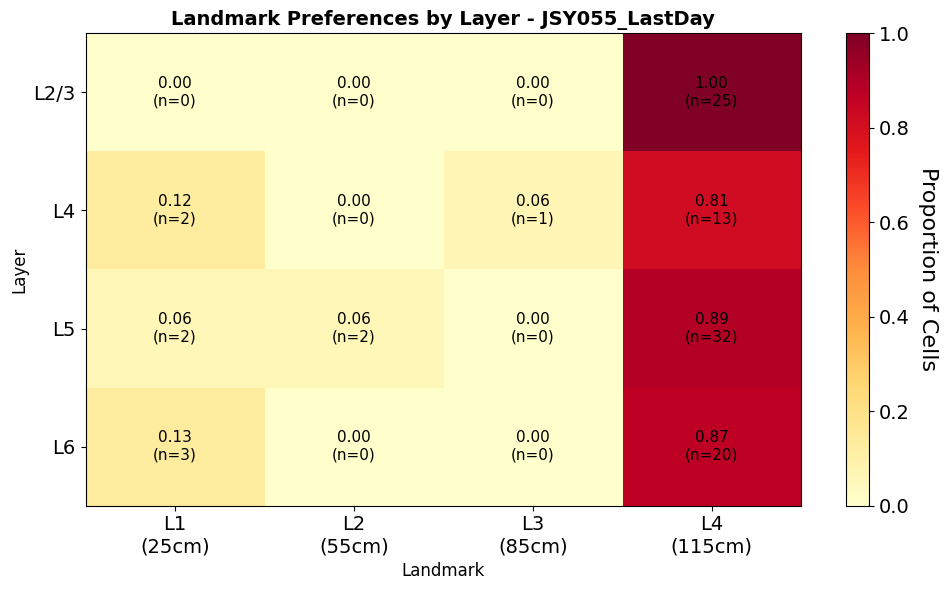

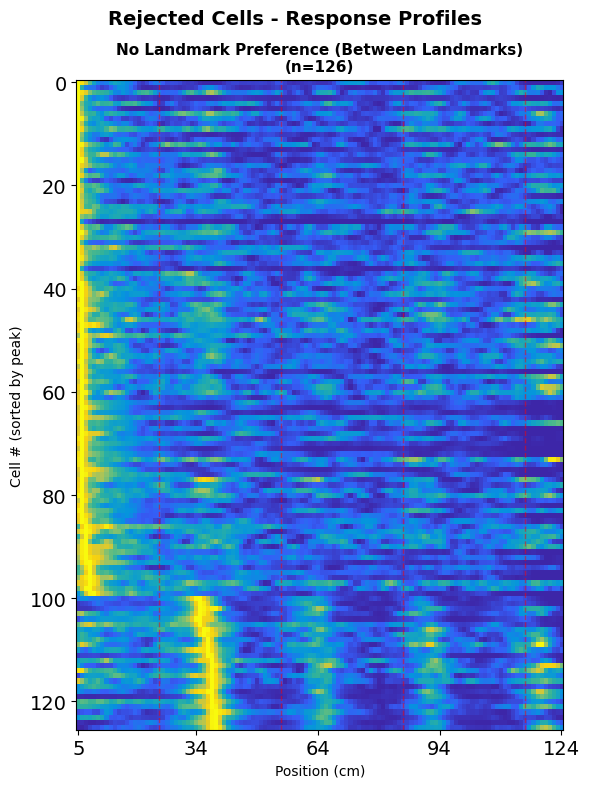

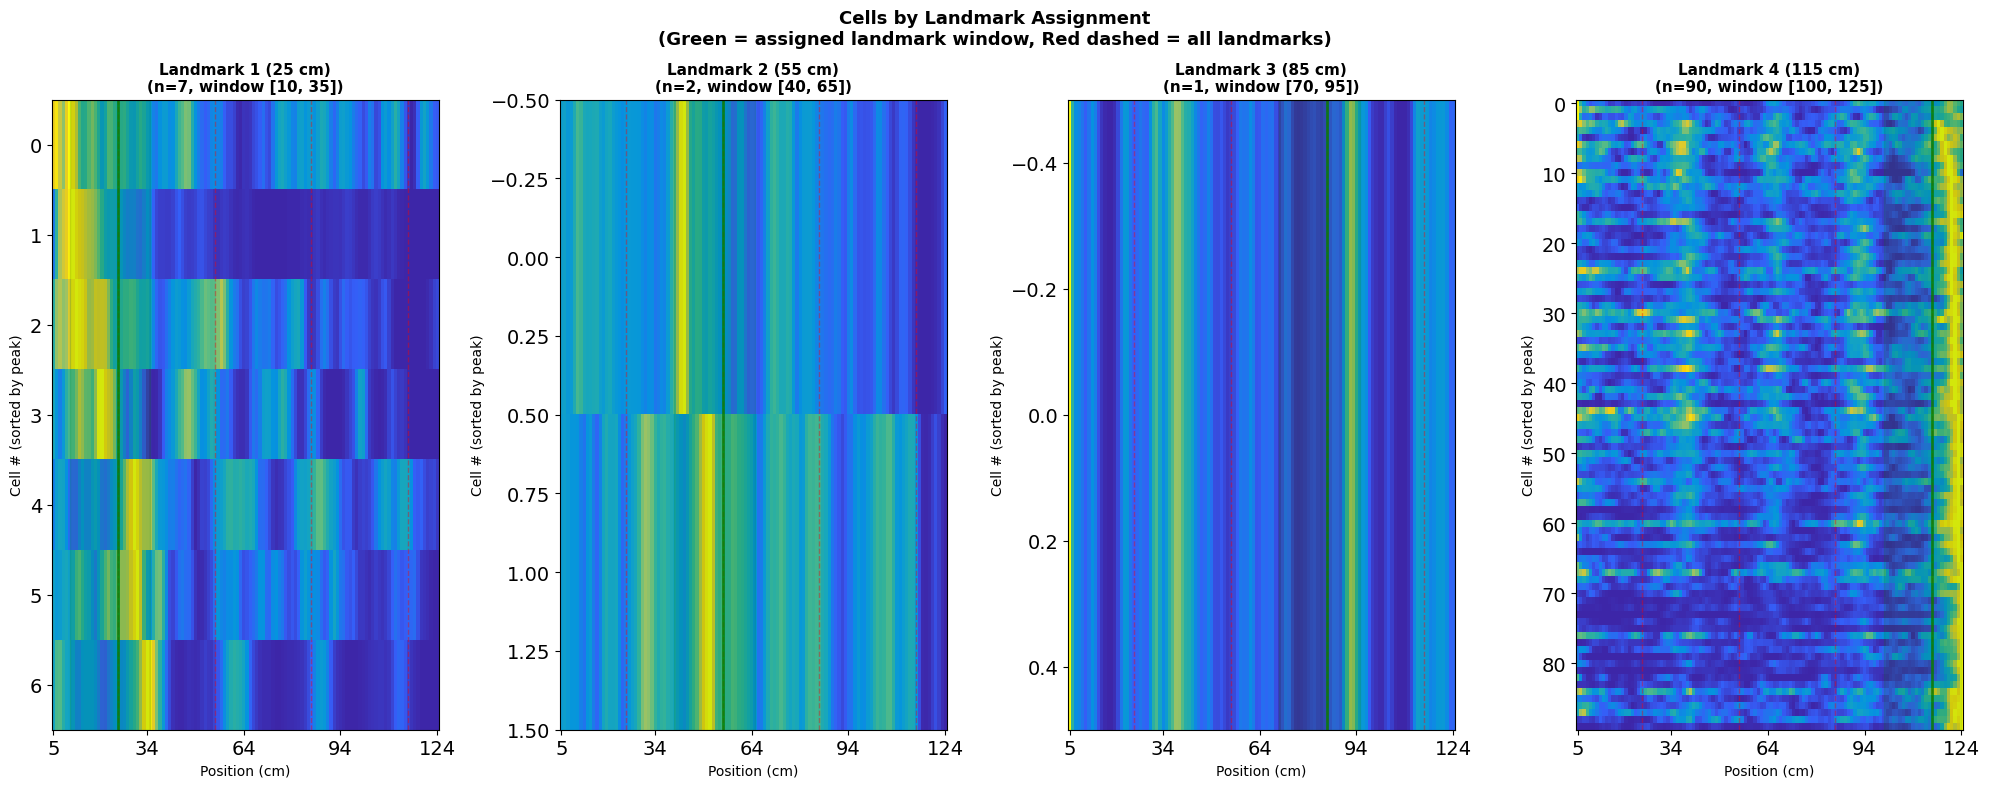

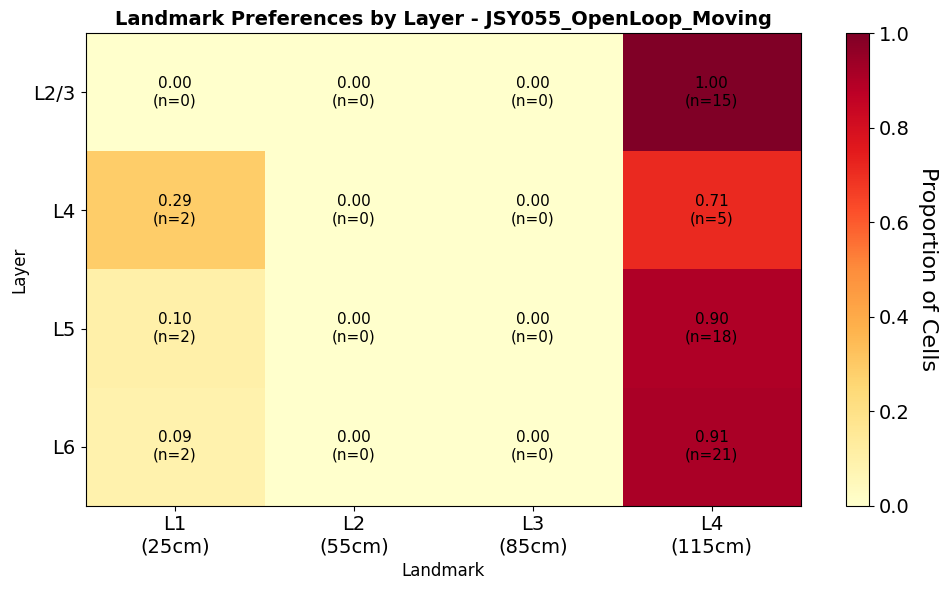

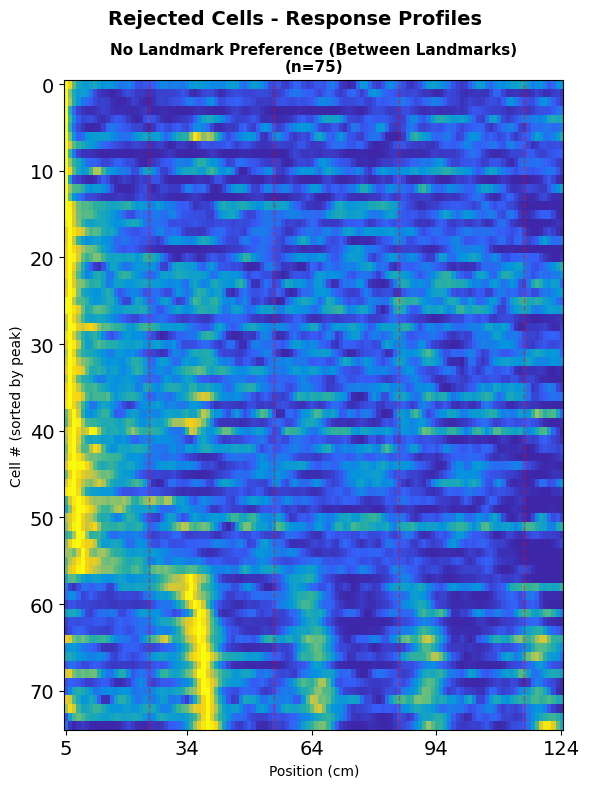

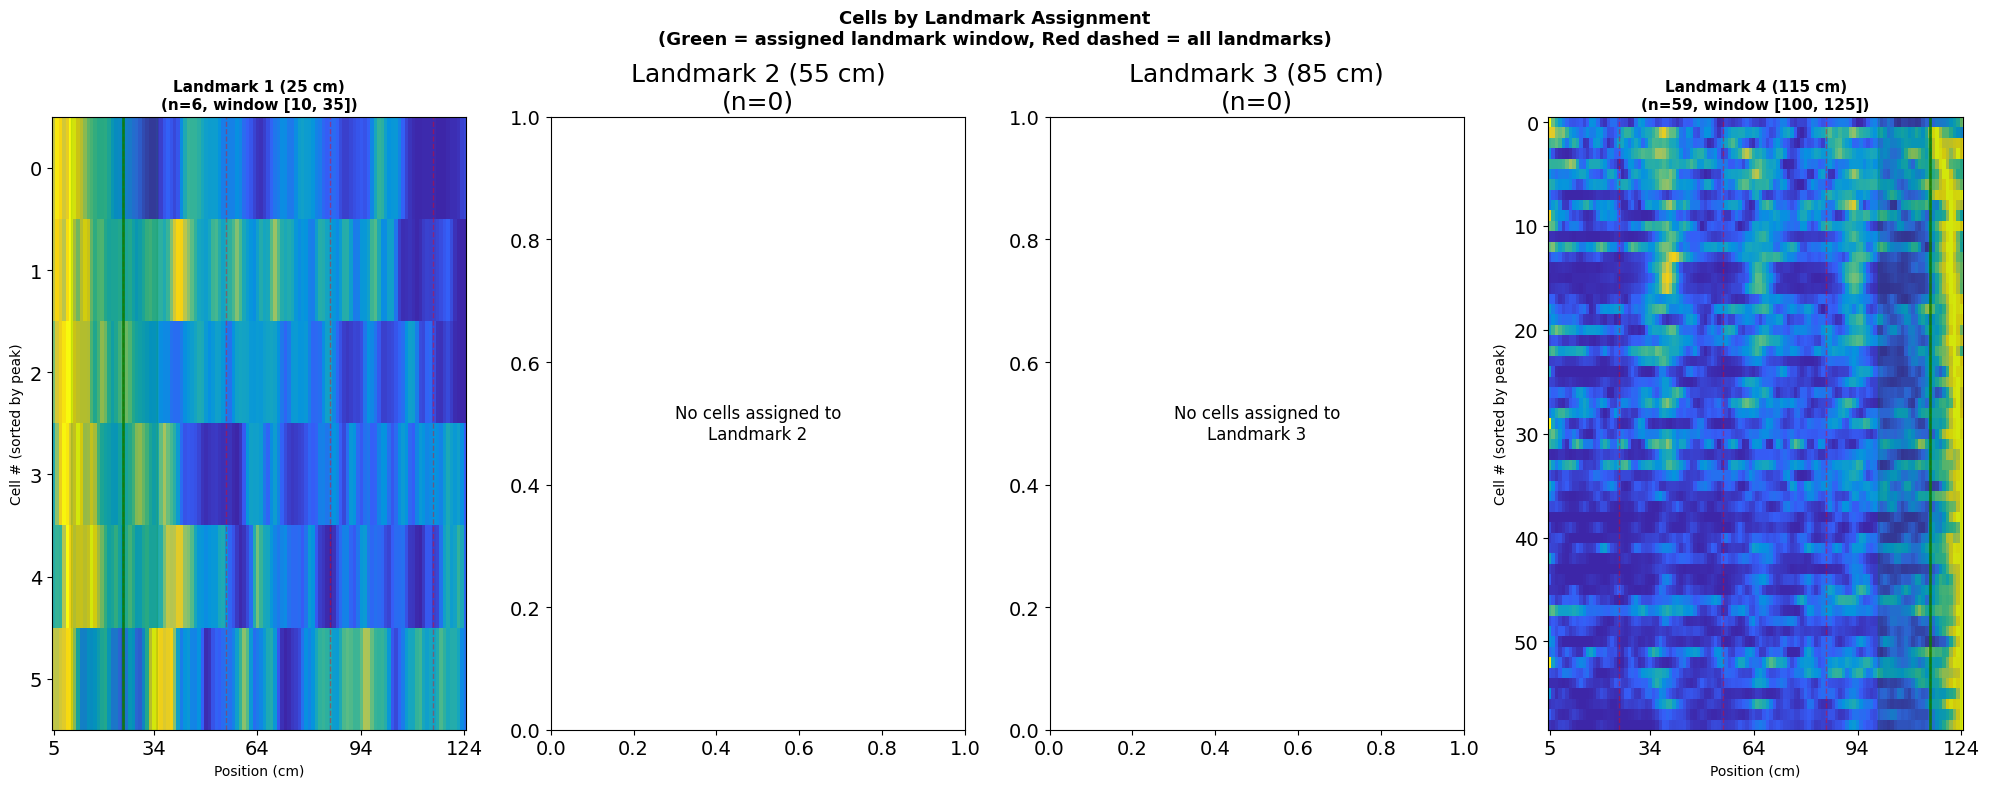

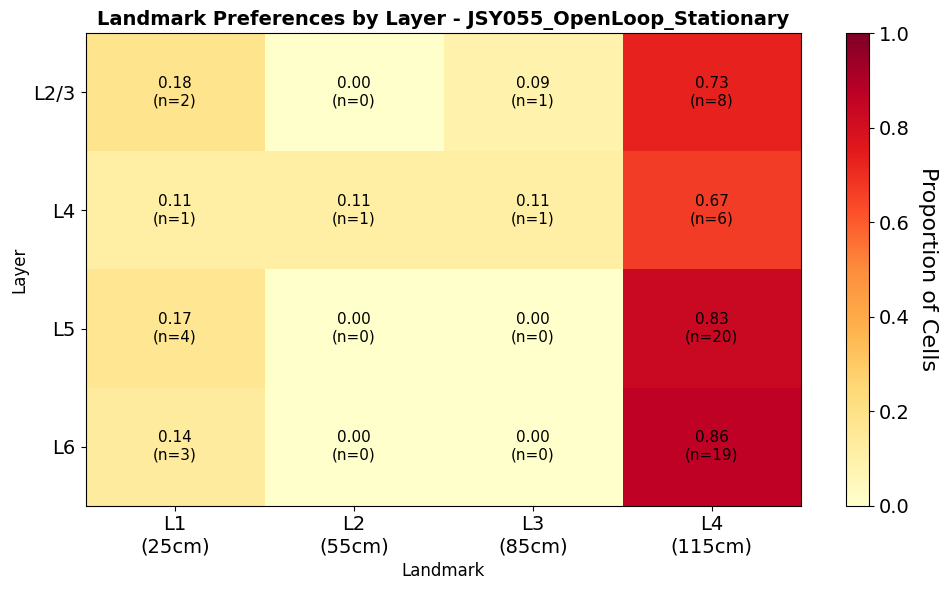

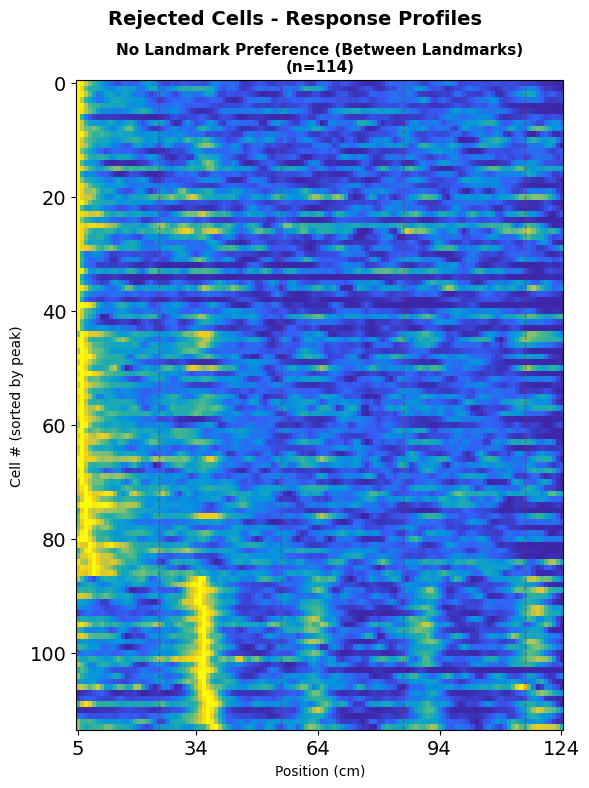

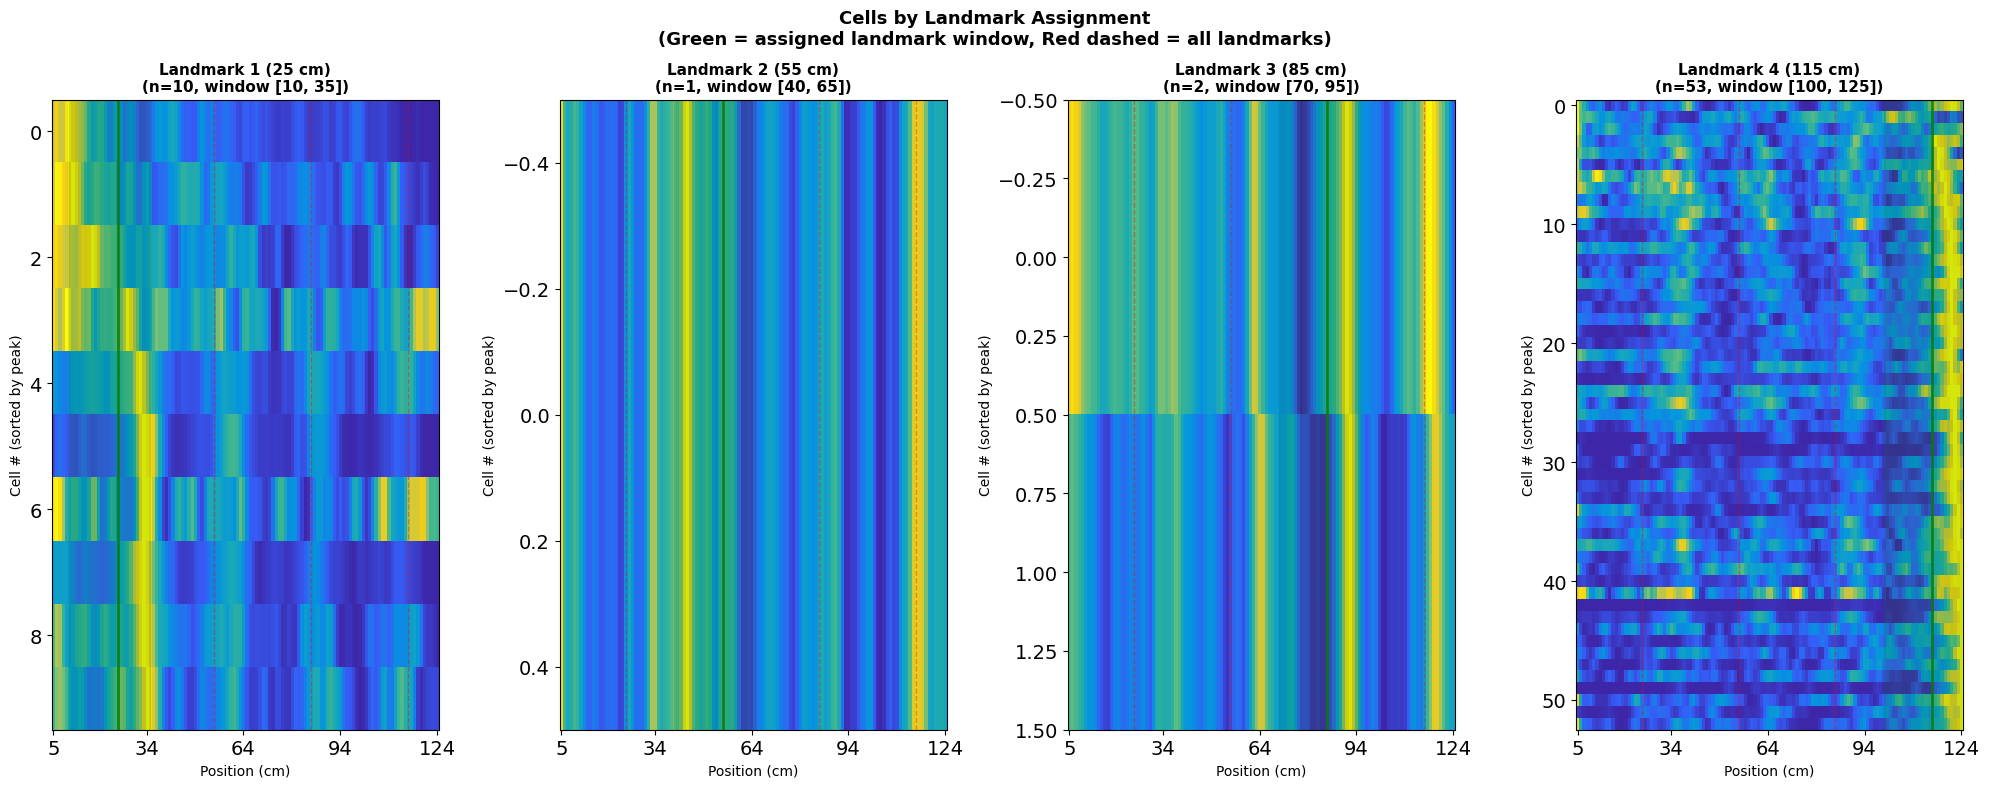

In [8]:
def run_session_landmark(session_dir, session_id, skip_existing=True):
    h5_out = os.path.join(session_dir, f'{session_id}_landmark_preferences.h5')

    if skip_existing and os.path.isfile(h5_out):
        print(f'    Skipped (exists): {os.path.basename(h5_out)}')
        return h5_out

    if not os.path.isdir(session_dir):
        raise FileNotFoundError(f'Directory not found: {session_dir}')

    preproc_files = glob.glob(os.path.join(session_dir, '*preproc*.h5'))
    if not preproc_files:
        raise ValueError(f'No preproc .h5 found in {session_dir}')

    preproc_data = hfiles.read_h5(preproc_files[0])
    norm_spatial = preproc_data['norm_spatial_activity']
    bin_centers  = preproc_data['bin_centers']
    reliable     = preproc_data['combined_reliable']
    # reliable     = preproc_data['reliable_cells']

    twoP_fn = os.path.basename(session_dir)
    raw_twop = TwoP(session_dir, twoP_fn)
    raw_twop.find_files()
    twop_dict  = raw_twop.calc_dFF()
    med_coords = np.array([cell['med'] for cell in twop_dict['stat']])
    layer_cells, _ = SMI_Layer.identify_layers(med_coords)

    # Pre-filter to reliable cells so all landmark-assigned cells appear in the heatmap.
    # Landmark assignment runs only on the reliable pool; reliable_valid_cells=ones
    # so analyze_layer_landmark_preferences applies no further intersection.
    reliable_idx = np.where(reliable)[0]
    norm_spatial_reliable = norm_spatial[reliable_idx]
    layer_cells_reliable = {
        layer: np.where(np.isin(reliable_idx, idx))[0]
        for layer, idx in layer_cells.items()
    }
    print(f'    Reliable cells: {len(reliable_idx)} / {len(reliable)}')

    run_landmark_analysis(
        normalized_spatial_activity=norm_spatial_reliable,
        bin_centers=bin_centers,
        layer_cells=layer_cells_reliable,
        reliable_valid_cells=np.ones(len(reliable_idx), dtype=bool),
        landmark_positions=LANDMARK_POSITIONS,
        landmark_windows_config=LANDMARK_WINDOWS_CONFIG,
        landmark_window=10.0,
        boundary_exclusion=(5, 5),
        exclude_first_bins=5,
        exclude_last_bins=5,
        trials_per_block=20,
        smoothing_sigma=1.0,
        save_path=session_dir,
        session_id=session_id,
        date_str=None,
    )
    return h5_out


os.makedirs(ACROSS_ANIMALS_DIR, exist_ok=True)
included_sessions = [s for s in SESSIONS if s['animal_id'] in INCLUDE_ANIMALS]

for s in included_sessions:
    print(f'=== {s["animal_id"]} ===')
    os.makedirs(s['output_dir'], exist_ok=True)
    for cond in CONDITIONS:
        print(f'  {cond}:')
        try:
            run_session_landmark(s[cond], session_id=f'{s["animal_id"]}_{cond}', skip_existing=False)
        except Exception as e:
            print(f'    ERROR: {e}')
            traceback.print_exc()

print('Analysis runs complete.')

---
## Part 2 -- Load Results

Reads `{condition}_landmark_preferences.h5` from each TSeries folder.

In [9]:
def load_landmark_h5(h5_path):
    if not os.path.isfile(h5_path):
        return None
    out = {}
    with h5py.File(h5_path, 'r') as f:
        if 'full_session' not in f:
            return None
        for safe_layer in f['full_session'].keys():
            grp  = f['full_session'][safe_layer]
            orig = grp.attrs.get('original_name', safe_layer)
            out[orig] = {
                'proportions': grp['landmark_proportions'][:],
                'counts':      grp['landmark_counts'][:],
                'n_cells':     int(grp.attrs.get('n_cells', 0)),
            }
    return out


all_data = {}

for s in included_sessions:
    animal = s['animal_id']
    all_data[animal] = {}
    for cond in CONDITIONS:
        h5_path = os.path.join(s[cond], f'{animal}_{cond}_landmark_preferences.h5')
        data = load_landmark_h5(h5_path)
        all_data[animal][cond] = data
        if data is not None:
            layers_ok = [lyr for lyr, d in data.items() if d['n_cells'] > 0]
            print(f'{animal:8s}  {cond:22s}  layers: {layers_ok}')
        else:
            print(f'{animal:8s}  {cond:22s}  NOT FOUND -- {h5_path}')

animals = [s['animal_id'] for s in included_sessions]
print(f'\nLoaded {len(all_data)} animals: {animals}')

JSY055    LastDay                 layers: ['L2/3', 'L4', 'L5', 'L6']
JSY055    OpenLoop_Moving         layers: ['L2/3', 'L4', 'L5', 'L6']
JSY055    OpenLoop_Stationary     layers: ['L2/3', 'L4', 'L5', 'L6']

Loaded 1 animals: ['JSY055']


---
## Figure 1 -- Per-Animal Stacked Bar Comparison

Each panel = one cortical layer. X-axis = condition, stacked bars = proportion of cells preferring each landmark.

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis\LandmarkPreference_day7\LandmarkPref_Stacked_JSY055.png


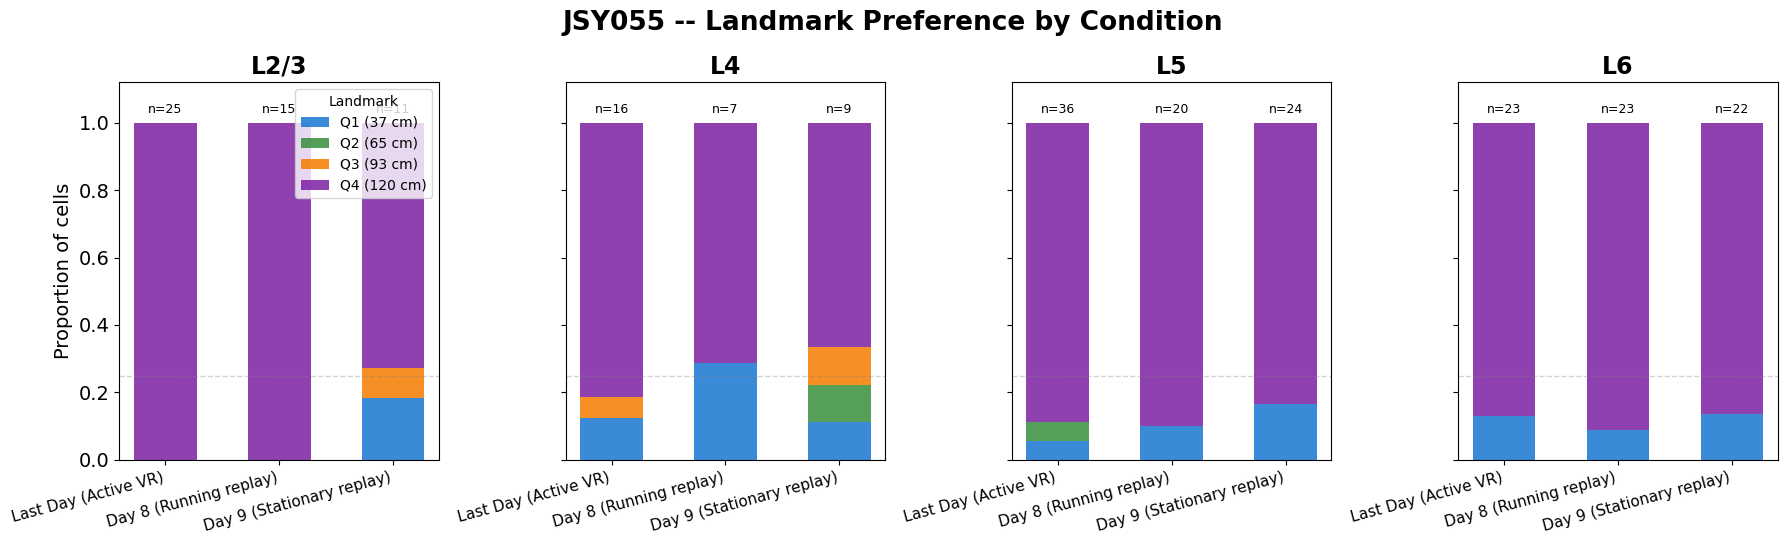

In [10]:
def plot_stacked_landmark_comparison(animal_id, animal_cond_data, output_dir):
    n_layers = len(LAYER_NAMES)
    fig, axes = plt.subplots(1, n_layers, figsize=(4.5 * n_layers, 5.5), sharey=True)

    x = np.arange(len(CONDITIONS))
    bar_w = 0.55

    for ax, layer in zip(axes, LAYER_NAMES):
        bottom = np.zeros(len(CONDITIONS))
        for lm_idx, (lm_label, lm_color) in enumerate(zip(LANDMARK_LABELS, LANDMARK_COLORS)):
            vals = []
            for cond in CONDITIONS:
                cd = animal_cond_data.get(cond)
                if cd and layer in cd and cd[layer]['n_cells'] > 0:
                    vals.append(float(cd[layer]['proportions'][lm_idx]))
                else:
                    vals.append(np.nan)
            vals  = np.array(vals)
            valid = ~np.isnan(vals)
            if valid.any():
                ax.bar(x[valid], vals[valid], bar_w, bottom=bottom[valid],
                       label=lm_label, color=lm_color, alpha=0.85)
                bottom[valid] += vals[valid]

        ax.set_title(layer, fontsize=17, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(COND_LABELS, fontsize=11, rotation=15, ha='right')
        ax.set_ylim(0, 1.12)
        ax.axhline(0.25, color='gray', lw=1, ls='--', alpha=0.35)

        for ci, cond in enumerate(CONDITIONS):
            cd = animal_cond_data.get(cond)
            if cd and layer in cd:
                ax.text(ci, 1.02, f'n={cd[layer]["n_cells"]}',
                        ha='center', va='bottom', fontsize=9)

    axes[0].set_ylabel('Proportion of cells', fontsize=14)
    axes[0].legend(loc='upper right', fontsize=10, title='Landmark', title_fontsize=10)

    fig.suptitle(f'{animal_id} -- Landmark Preference by Condition',
                 fontsize=19, fontweight='bold')
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f'LandmarkPref_Stacked_{animal_id}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


for s in included_sessions:
    plot_stacked_landmark_comparison(s['animal_id'], all_data[s['animal_id']], s['output_dir'])

---
## Figure 2 -- Cross-Animal Grouped Bar

Mean (+/- SEM) landmark proportion per condition across animals. Dots = individual animals. Dashed line = uniform preference (0.25).

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\LandmarkPref_GroupedBar_AllAnimals.png


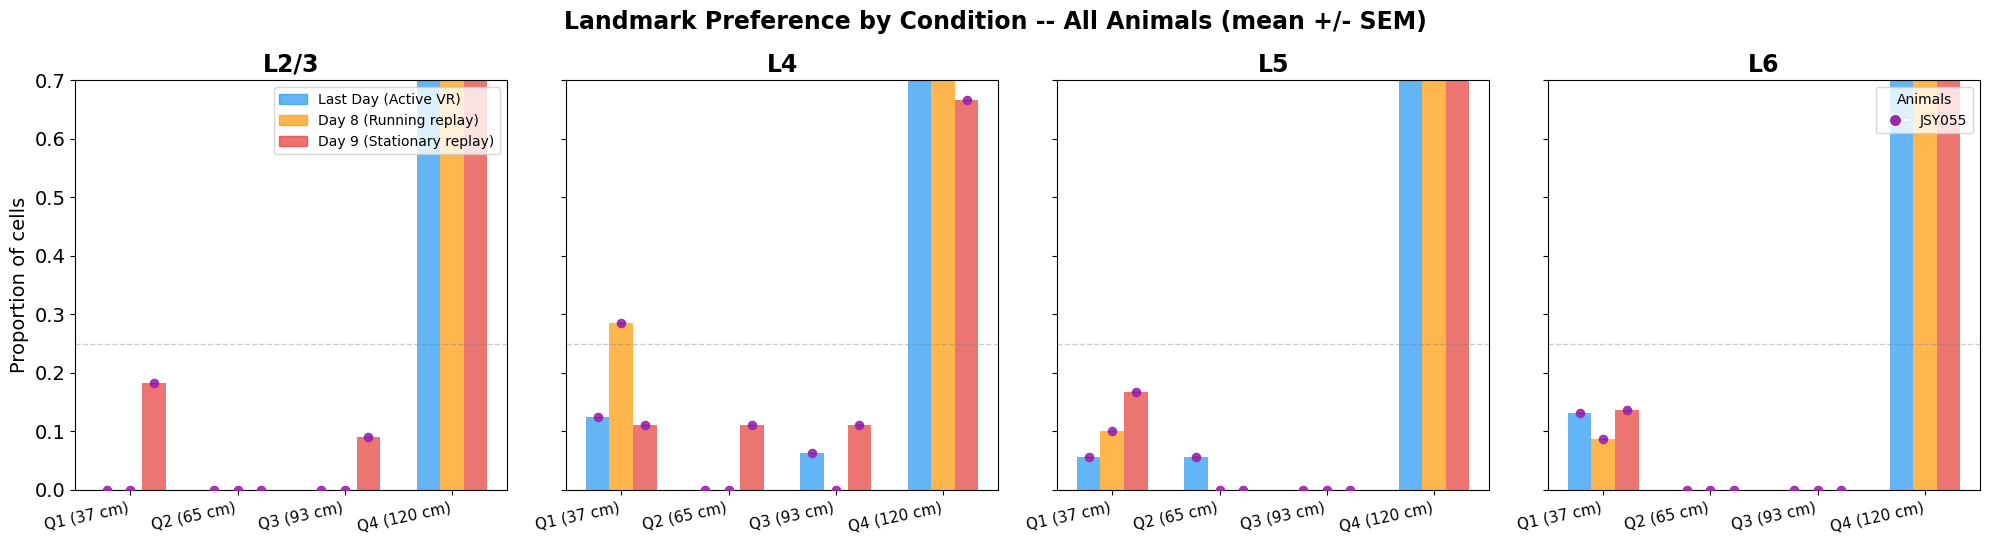

In [11]:
def plot_cross_animal_grouped(all_data, animals, layer_names):
    n_layers = len(layer_names)
    n_conds  = len(CONDITIONS)
    n_lm     = len(LANDMARK_POSITIONS)

    fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5.5), sharey=True)
    bar_w = 0.22
    x = np.arange(n_lm)

    for ax, layer in zip(axes, layer_names):
        for ci, (cond, cond_label, cond_color) in enumerate(
                zip(CONDITIONS, COND_LABELS, COND_COLORS)):
            animal_props = []
            for animal in animals:
                cd = all_data[animal].get(cond)
                if cd and layer in cd and cd[layer]['n_cells'] > 0:
                    animal_props.append(cd[layer]['proportions'].copy())
                else:
                    animal_props.append(np.full(n_lm, np.nan))
            animal_props = np.array(animal_props)

            n_valid    = np.sum(~np.isnan(animal_props[:, 0]))
            mean_props = np.nanmean(animal_props, axis=0)
            sem_props  = np.nanstd(animal_props, axis=0) / np.maximum(np.sqrt(n_valid), 1)

            offset = (ci - (n_conds - 1) / 2) * bar_w
            ax.bar(x + offset, mean_props, bar_w,
                   label=cond_label, color=cond_color, alpha=0.70,
                   yerr=sem_props, capsize=3, error_kw={'lw': 1.5})

            for ai, (animal, anim_color) in enumerate(zip(animals, ANIMAL_COLORS)):
                ax.scatter(x + offset, animal_props[ai], s=35,
                           color=anim_color, zorder=5, alpha=0.9)

        ax.set_title(layer, fontsize=17, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(LANDMARK_LABELS, fontsize=11, rotation=12, ha='right')
        ax.axhline(0.25, color='gray', lw=1, ls='--', alpha=0.4)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_ylim(0, 0.70)

    axes[0].set_ylabel('Proportion of cells', fontsize=14)

    cond_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.7)
                    for c in COND_COLORS]
    axes[0].legend(cond_handles, COND_LABELS, fontsize=10, loc='upper right')

    anim_handles = [Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=c, markersize=9, label=a)
                    for a, c in zip(animals, ANIMAL_COLORS)]
    axes[-1].legend(handles=anim_handles, fontsize=10, title='Animals', loc='upper right')

    fig.suptitle('Landmark Preference by Condition -- All Animals (mean +/- SEM)',
                 fontsize=17, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(ACROSS_ANIMALS_DIR, 'LandmarkPref_GroupedBar_AllAnimals.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


plot_cross_animal_grouped(all_data, animals, LAYER_NAMES)

---
## Figure 3 -- Delta Proportion (Replay minus Last Day)

Shows how landmark preference proportions shift going from Last Day to replay conditions.

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\LandmarkPref_Delta_AllAnimals.png


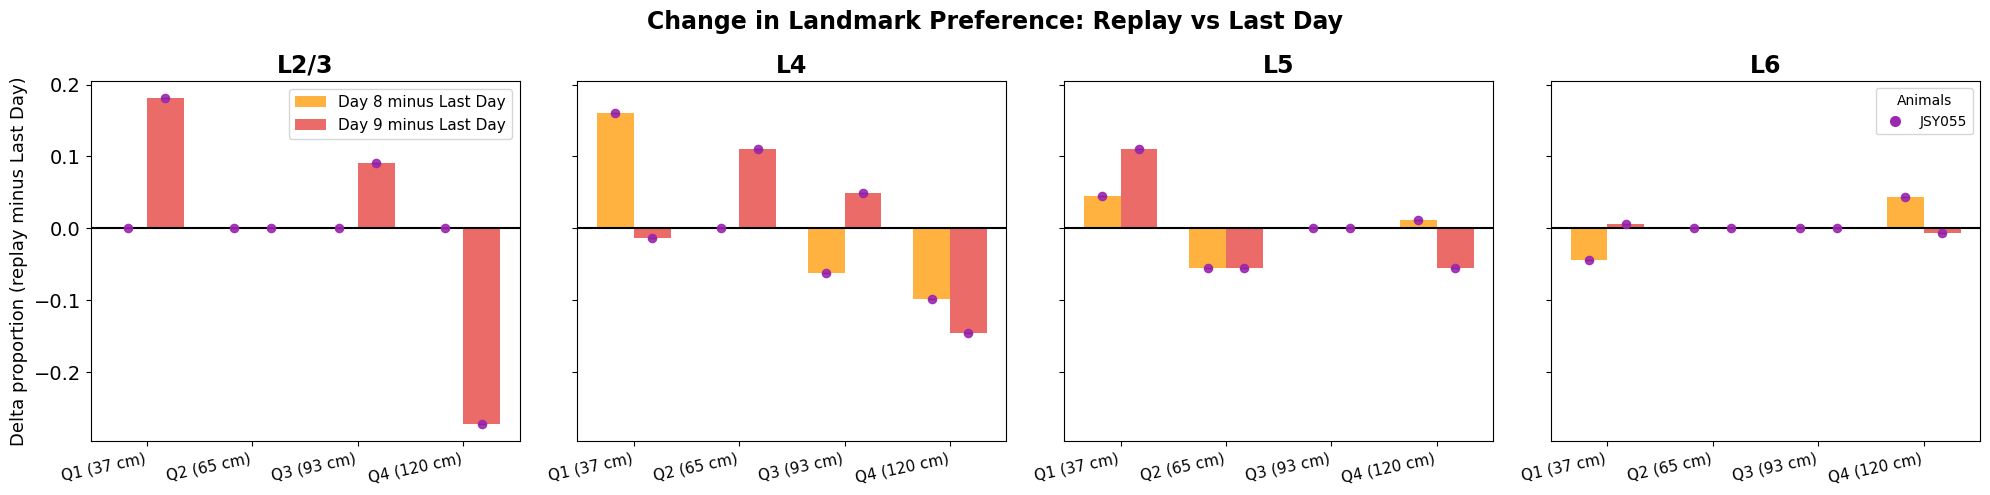

In [12]:
def plot_delta_proportion(all_data, animals, layer_names):
    n_layers = len(layer_names)
    n_lm     = len(LANDMARK_POSITIONS)
    replay_conds  = ['OpenLoop_Moving', 'OpenLoop_Stationary']
    replay_labels = ['Day 8 minus Last Day', 'Day 9 minus Last Day']
    replay_colors = [COND_COLORS[1], COND_COLORS[2]]

    fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 5), sharey=True)
    bar_w = 0.35
    x = np.arange(n_lm)

    for ax, layer in zip(axes, layer_names):
        for ci, (cond, cond_label, cond_color) in enumerate(
                zip(replay_conds, replay_labels, replay_colors)):
            deltas = []
            for animal in animals:
                last = all_data[animal].get('LastDay')
                rep  = all_data[animal].get(cond)
                if (last and rep and
                        layer in last and layer in rep and
                        last[layer]['n_cells'] > 0 and rep[layer]['n_cells'] > 0):
                    deltas.append(rep[layer]['proportions'] - last[layer]['proportions'])
                else:
                    deltas.append(np.full(n_lm, np.nan))
            deltas  = np.array(deltas)
            n_valid = np.sum(~np.isnan(deltas[:, 0]))
            mean_d  = np.nanmean(deltas, axis=0)
            sem_d   = np.nanstd(deltas, axis=0) / np.maximum(np.sqrt(n_valid), 1)

            offset = (ci - 0.5) * bar_w
            ax.bar(x + offset, mean_d, bar_w,
                   label=cond_label, color=cond_color, alpha=0.75,
                   yerr=sem_d, capsize=3, error_kw={'lw': 1.5})

            for ai, (animal, anim_color) in enumerate(zip(animals, ANIMAL_COLORS)):
                ax.scatter(x + offset, deltas[ai], s=35,
                           color=anim_color, zorder=5, alpha=0.9)

        ax.axhline(0, color='k', lw=1.5)
        ax.set_title(layer, fontsize=17, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(LANDMARK_LABELS, fontsize=11, rotation=12, ha='right')

    axes[0].set_ylabel('Delta proportion (replay minus Last Day)', fontsize=13)
    axes[0].legend(fontsize=11, loc='upper right')

    anim_handles = [Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=c, markersize=9, label=a)
                    for a, c in zip(animals, ANIMAL_COLORS)]
    axes[-1].legend(handles=anim_handles, fontsize=10, title='Animals', loc='upper right')

    fig.suptitle('Change in Landmark Preference: Replay vs Last Day',
                 fontsize=17, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(ACROSS_ANIMALS_DIR, 'LandmarkPref_Delta_AllAnimals.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


plot_delta_proportion(all_data, animals, LAYER_NAMES)

---
## Statistics

Chi-square test of independence comparing landmark count distributions between conditions per layer.

LANDMARK PREFERENCE STATISTICS
Chi-square contingency test: LastDay vs replay conditions

--- JSY055 ---

  L2/3
    LastDay: counts=[ 0  0  0 25]  n=25
    OpenLoop_Moving: counts=[ 0  0  0 15]  n=15
    OpenLoop_Stationary: counts=[2 0 1 8]  n=11
    LastDay vs OpenLoop_Moving: insufficient counts
    LastDay vs OpenLoop_Stationary: insufficient counts

  L4
    LastDay: counts=[ 2  0  1 13]  n=16
    OpenLoop_Moving: counts=[2 0 0 5]  n=7
    OpenLoop_Stationary: counts=[1 1 1 6]  n=9
    LastDay vs OpenLoop_Moving: insufficient counts
    LastDay vs OpenLoop_Stationary: insufficient counts

  L5
    LastDay: counts=[ 2  2  0 32]  n=36
    OpenLoop_Moving: counts=[ 2  0  0 18]  n=20
    OpenLoop_Stationary: counts=[ 4  0  0 20]  n=24
    LastDay vs OpenLoop_Moving: insufficient counts
    LastDay vs OpenLoop_Stationary: insufficient counts

  L6
    LastDay: counts=[ 3  0  0 20]  n=23
    OpenLoop_Moving: counts=[ 2  0  0 21]  n=23
    OpenLoop_Stationary: counts=[ 3  0  0 19]  n=22

ValueError: max() arg is an empty sequence

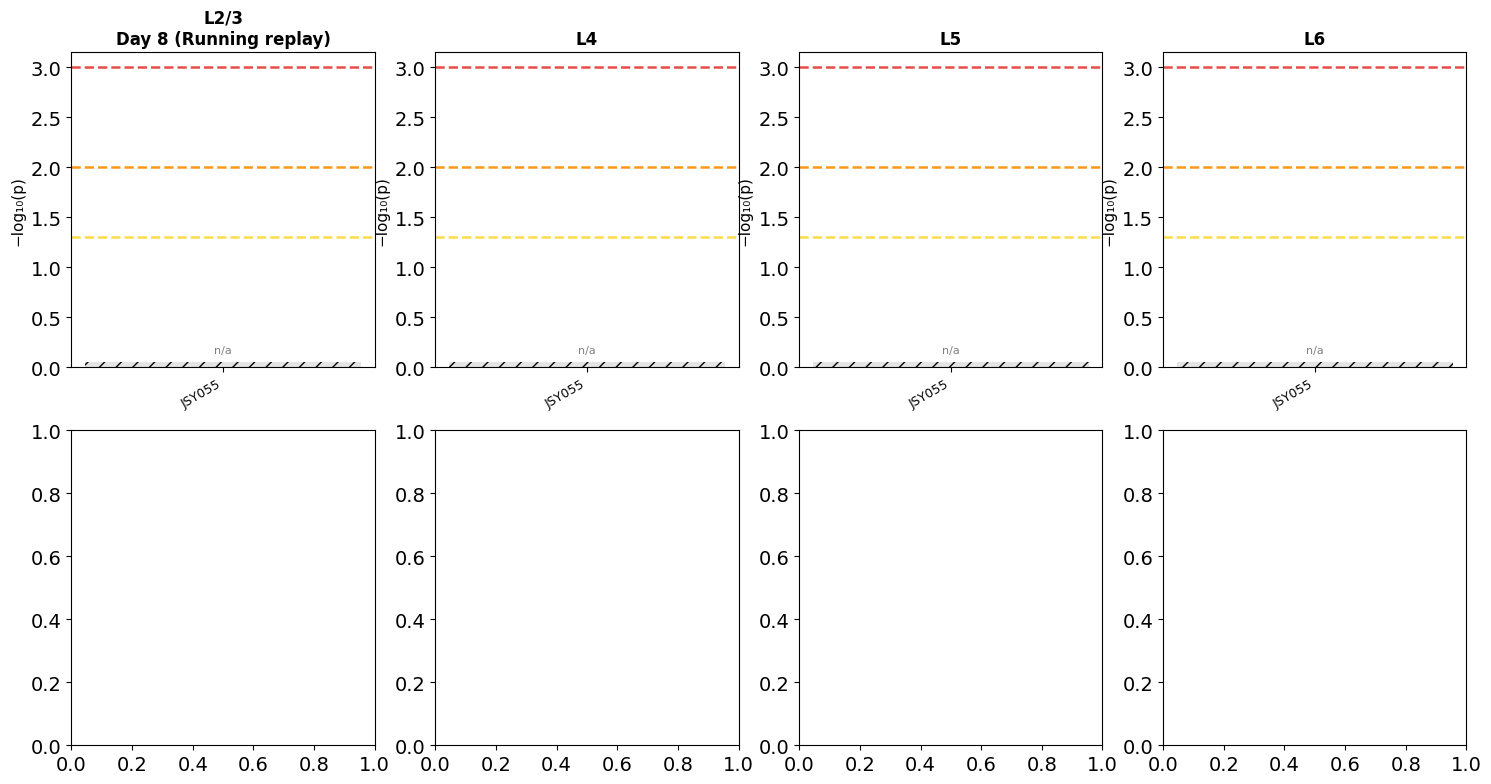

In [13]:
print('=' * 70)
print('LANDMARK PREFERENCE STATISTICS')
print('Chi-square contingency test: LastDay vs replay conditions')
print('=' * 70)

for animal in animals:
    print(f'\n--- {animal} ---')
    for layer in LAYER_NAMES:
        print(f'\n  {layer}')
        cond_counts = []
        for cond in CONDITIONS:
            cd = all_data[animal].get(cond)
            if cd and layer in cd and cd[layer]['n_cells'] > 0:
                counts = cd[layer]['counts']
                print(f'    {cond}: counts={counts}  n={cd[layer]["n_cells"]}')
                cond_counts.append(counts)
            else:
                print(f'    {cond}: no data')
                cond_counts.append(None)

        for other_idx, other_label in [(1, 'LastDay vs OpenLoop_Moving'),
                                        (2, 'LastDay vs OpenLoop_Stationary')]:
            if cond_counts[0] is None or cond_counts[other_idx] is None:
                continue
            table = np.array([cond_counts[0], cond_counts[other_idx]])
            if np.all(table >= 1) and np.all(table.sum(axis=1) > 0):
                chi2, p, dof, _ = chi2_contingency(table)
                sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
                print(f'    {other_label}: chi2={chi2:.3f}, dof={dof}, p={p:.4f}  {sig}')
            else:
                print(f'    {other_label}: insufficient counts')


# ── Statistics Visualization ────────────────────────────────────────────────────
# Build p-value matrix: [n_animals, n_layers, 2 comparisons]
COMPARISONS    = [('OpenLoop_Moving', 'Day 8 (Running replay)'),
                  ('OpenLoop_Stationary', 'Day 9 (Stationary replay)')]
COMP_COLORS    = [COND_COLORS[1], COND_COLORS[2]]

p_mat   = np.full((len(animals), len(LAYER_NAMES), 2), np.nan)
chi2_mat = np.full_like(p_mat, np.nan)

for ai, animal in enumerate(animals):
    for li, layer in enumerate(LAYER_NAMES):
        last_cd = all_data[animal].get('LastDay')
        if not last_cd or layer not in last_cd or last_cd[layer]['n_cells'] == 0:
            continue
        last_counts = last_cd[layer]['counts']

        for ci, (cond, _) in enumerate(COMPARISONS):
            rep_cd = all_data[animal].get(cond)
            if not rep_cd or layer not in rep_cd or rep_cd[layer]['n_cells'] == 0:
                continue
            rep_counts = rep_cd[layer]['counts']
            table = np.array([last_counts, rep_counts])
            if np.all(table >= 1) and np.all(table.sum(axis=1) > 0):
                chi2, p, dof, _ = chi2_contingency(table)
                p_mat[ai, li, ci]    = p
                chi2_mat[ai, li, ci] = chi2

# ── Panel A: -log10(p) bar chart — 2 rows (comparison) × 4 cols (layer) ────────
thresh_p   = [0.05, 0.01, 0.001]
thresh_nlp = [-np.log10(v) for v in thresh_p]
thresh_lbl = ['p=0.05 (*)', 'p=0.01 (**)', 'p=0.001 (***)']
thresh_clr = ['#FDD835', '#FB8C00', '#E53935']

x_anim = np.arange(len(animals))
bar_w  = 0.65

fig, axes = plt.subplots(len(COMPARISONS), len(LAYER_NAMES),
                          figsize=(4.5 * len(LAYER_NAMES), 4.5 * len(COMPARISONS)),
                          sharey=False)

for ci, (cond, comp_label) in enumerate(COMPARISONS):
    for li, layer in enumerate(LAYER_NAMES):
        ax = axes[ci, li]

        for ai, (animal, anim_color) in enumerate(zip(animals, ANIMAL_COLORS)):
            pval = p_mat[ai, li, ci]
            if np.isnan(pval):
                ax.bar(ai, 0.05, bar_w, color='#BDBDBD', alpha=0.4, hatch='//')
                ax.text(ai, 0.12, 'n/a', ha='center', va='bottom', fontsize=8, color='gray')
            else:
                nlp = -np.log10(pval)
                ax.bar(ai, nlp, bar_w, color=anim_color, alpha=0.88)
                sig = ('***' if pval < 0.001 else '**' if pval < 0.01
                       else '*' if pval < 0.05 else 'ns')
                ax.text(ai, nlp + 0.08, sig, ha='center', va='bottom',
                        fontsize=11, fontweight='bold',
                        color='#B71C1C' if pval < 0.05 else '#757575')

        # Threshold lines
        for tv, tl, tc in zip(thresh_nlp, thresh_lbl, thresh_clr):
            lkw = dict(color=tc, lw=1.8, ls='--', alpha=0.9)
            ax.axhline(tv, **lkw, label=tl if (ci == 0 and li == len(LAYER_NAMES) - 1) else '_')

        ax.set_xticks(x_anim)
        ax.set_xticklabels(animals, rotation=30, ha='right', fontsize=9)
        ax.set_ylabel('−log₁₀(p)', fontsize=11)

        title_top = comp_label if li == 0 else ''
        ax.set_title(f'{layer}\n{comp_label}' if li == 0 else layer,
                     fontsize=12, fontweight='bold')
        ax.set_ylim(bottom=0)

    # y-limit: shared across columns in each row
    row_max = max(
        np.nanmax(-np.log10(np.where(p_mat[:, li, ci] > 0, p_mat[:, li, ci], np.nan)))
        for li in range(len(LAYER_NAMES))
        if not np.all(np.isnan(p_mat[:, li, ci]))
    )
    for li in range(len(LAYER_NAMES)):
        axes[ci, li].set_ylim(0, max(row_max * 1.25, thresh_nlp[-1] * 1.3))

# Legend for threshold lines (only on last panel)
axes[0, -1].legend(fontsize=9, loc='upper right', title='Threshold', title_fontsize=9)

# Animal colour legend
anim_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.88, label=a)
                for a, c in zip(animals, ANIMAL_COLORS)]
fig.legend(handles=anim_handles, title='Animal', fontsize=10, title_fontsize=10,
           loc='lower center', ncol=len(animals), bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Significance of Landmark Preference Shift vs Last Day\n(Chi-square, per animal per layer)',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Statistics_Significance_Visualization.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()


# ── Panel B: Heatmap summary — rows = animals, cols = layers ─────────────────
# Two heatmaps side by side (one per comparison)
fig, axes = plt.subplots(1, len(COMPARISONS),
                          figsize=(5.5 * len(COMPARISONS), 4.5 + 0.5 * len(animals)),
                          sharey=True)

import matplotlib.colors as mcolors

# Use a diverging-like colormap where grey = n/a, colour ramp = significance
cmap_sig = plt.cm.YlOrRd
norm_sig  = mcolors.Normalize(vmin=0, vmax=max(thresh_nlp) * 1.1)

for ci, (cond, comp_label) in enumerate(COMPARISONS):
    ax = axes[ci]
    mat = -np.log10(np.where(p_mat[:, :, ci] > 0, p_mat[:, :, ci], np.nan))

    im = ax.imshow(mat, aspect='auto', cmap=cmap_sig, norm=norm_sig,
                   origin='upper')

    # Annotate each cell
    for ai in range(len(animals)):
        for li in range(len(LAYER_NAMES)):
            pval = p_mat[ai, li, ci]
            if np.isnan(pval):
                ax.text(li, ai, 'n/a', ha='center', va='center',
                        fontsize=10, color='#9E9E9E')
            else:
                sig = ('***' if pval < 0.001 else '**' if pval < 0.01
                       else '*' if pval < 0.05 else 'ns')
                ax.text(li, ai, sig, ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if pval < 0.01 else 'black')

    ax.set_xticks(np.arange(len(LAYER_NAMES)))
    ax.set_xticklabels(LAYER_NAMES, fontsize=12)
    ax.set_yticks(np.arange(len(animals)))
    ax.set_yticklabels(animals, fontsize=12)
    ax.set_title(f'{comp_label}\nvs Last Day', fontsize=13, fontweight='bold')

    plt.colorbar(im, ax=ax, label='−log₁₀(p)', shrink=0.75)

# Grey-out n/a cells with a hatched patch
for ci in range(len(COMPARISONS)):
    ax = axes[ci]
    for ai in range(len(animals)):
        for li in range(len(LAYER_NAMES)):
            if np.isnan(p_mat[ai, li, ci]):
                ax.add_patch(plt.Rectangle((li - 0.5, ai - 0.5), 1, 1,
                                            fill=True, color='#EEEEEE', zorder=0))

# Add threshold reference lines (horizontal between rows) — skip, covered by annotation

fig.suptitle('Significance Heatmap: Landmark Preference vs Last Day', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Statistics_Heatmap.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

---
## Figure 4 -- Proportion Heatmaps (All Animals Combined)

Landmark preference proportion heatmaps pooled across all included animals.
Color = proportion of cells (YlOrRd, 0–0.8); each cell annotated with proportion and pooled n.

- **Plot 1**: one panel per condition — rows = layers, cols = landmarks
- **Plot 2**: one panel per layer — rows = conditions, cols = landmarks (shows how preference shifts across days)

In [ ]:
def _pool_layer_heatmap(all_data, include_animals, condition):
    """Pool counts across animals for one condition. Returns (prop, counts) shape (n_layers, n_lm)."""
    n_lm = len(LANDMARK_POSITIONS)
    props  = np.full((len(LAYER_NAMES), n_lm), np.nan)
    counts = np.zeros((len(LAYER_NAMES), n_lm), dtype=int)
    for li, layer in enumerate(LAYER_NAMES):
        total = np.zeros(n_lm, dtype=int)
        for animal in include_animals:
            cd = all_data[animal].get(condition)
            if cd and layer in cd and cd[layer]['n_cells'] > 0:
                total += cd[layer]['counts']
        n = total.sum()
        if n > 0:
            counts[li] = total
            props[li]  = total / n
    return props, counts


def _pool_condition_heatmap(all_data, include_animals, layer):
    """Pool counts across animals for one layer. Returns (prop, counts) shape (n_conditions, n_lm)."""
    n_lm = len(LANDMARK_POSITIONS)
    props  = np.full((len(CONDITIONS), n_lm), np.nan)
    counts = np.zeros((len(CONDITIONS), n_lm), dtype=int)
    for ci, cond in enumerate(CONDITIONS):
        total = np.zeros(n_lm, dtype=int)
        for animal in include_animals:
            cd = all_data[animal].get(cond)
            if cd and layer in cd and cd[layer]['n_cells'] > 0:
                total += cd[layer]['counts']
        n = total.sum()
        if n > 0:
            counts[ci] = total
            props[ci]  = total / n
    return props, counts


def _draw_prop_heatmap(ax, prop_mat, count_mat, row_labels, title, vmax=0.8):
    """Draw a proportion heatmap following plot_layer_landmark_heatmap style."""
    n_rows, n_cols = prop_mat.shape
    lm_xlabels = [f'Q{i+1}\n({p:.0f}cm)' for i, p in enumerate(LANDMARK_POSITIONS)]

    display = np.where(np.isnan(prop_mat), 0, prop_mat)
    im = ax.imshow(display, cmap='YlOrRd', aspect='auto', vmin=0, vmax=vmax)

    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(lm_xlabels, fontsize=10)
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(row_labels, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Landmark', fontsize=11)

    for i in range(n_rows):
        for j in range(n_cols):
            val = prop_mat[i, j]
            if np.isnan(val):
                ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='#AAAAAA')
            else:
                cnt = count_mat[i, j]
                txt = f'{val:.2f}\n(n={cnt})'
                color = 'white' if val > vmax * 0.65 else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color)
    return im


VMAX_HEAT = 0.8

# ── PLOT 1: One heatmap per condition — rows = layers, cols = landmarks ────────
fig, axes = plt.subplots(1, len(CONDITIONS),
                          figsize=(4.5 * len(CONDITIONS), 2.5 + 0.9 * len(LAYER_NAMES)))

for ax, cond, cond_label in zip(axes, CONDITIONS, COND_LABELS):
    prop_mat, cnt_mat = _pool_layer_heatmap(all_data, INCLUDE_ANIMALS, cond)
    im = _draw_prop_heatmap(ax, prop_mat, cnt_mat, LAYER_NAMES, cond_label, vmax=VMAX_HEAT)

axes[0].set_ylabel('Layer', fontsize=12)
plt.colorbar(im, ax=axes[-1], label='Proportion of cells', shrink=0.85)

fig.suptitle('Landmark Preference — All Animals Pooled, All Layers\n(rows = layers, cols = landmarks)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Heatmap_AllLayers_PerCondition.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


# ── PLOT 2: One heatmap per layer — rows = conditions, cols = landmarks ────────
fig, axes = plt.subplots(1, len(LAYER_NAMES),
                          figsize=(4.2 * len(LAYER_NAMES), 2.5 + 1.0 * len(CONDITIONS)),
                          sharey=True)

for ax, layer in zip(axes, LAYER_NAMES):
    prop_mat, cnt_mat = _pool_condition_heatmap(all_data, INCLUDE_ANIMALS, layer)
    im = _draw_prop_heatmap(ax, prop_mat, cnt_mat, COND_LABELS, layer, vmax=VMAX_HEAT)

axes[0].set_ylabel('Condition', fontsize=12)
plt.colorbar(im, ax=axes[-1], label='Proportion of cells', shrink=0.85)

fig.suptitle('Landmark Preference — All Animals Pooled, Per Layer\n(rows = conditions, cols = landmarks)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Heatmap_PerLayer_PerCondition.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

---
## Figure 4b -- Waterfall Plots (All Animals Combined)

Matches the format of the per-animal landmark analysis waterfall plots:
PARULA colormap · min-max normalised per cell · sorted by peak position within each landmark group ·
red dashed lines = all landmark positions · green solid + shaded = assigned landmark window.

- **Plot 1**: 3 rows × 4 cols — rows = conditions (Last Day → Day 9), cols = landmarks — **all layers pooled**
- **Plot 2**: same layout, one figure per cortical layer

In [ ]:
import matplotlib.colors as mcolors

# ── Parula colormap — identical to LandmarkPrefernce_SingleSessionAnalysis.py ──
_PARULA_COLORS = [
    (0.2422, 0.1504, 0.6603), (0.2108, 0.3706, 0.9717),
    (0.0196, 0.5804, 0.8745), (0.0863, 0.6510, 0.7490),
    (0.1961, 0.6980, 0.6039), (0.3647, 0.7412, 0.5176),
    (0.6275, 0.7647, 0.3843), (0.8510, 0.7882, 0.1961),
    (0.9686, 0.8235, 0.0667), (0.9765, 0.9843, 0.0510),
]
PARULA = mcolors.LinearSegmentedColormap.from_list('parula', _PARULA_COLORS)

# Landmark windows from LANDMARK_WINDOWS_CONFIG
LM_WINDOWS = [(pos - cfg['before'], pos + cfg['after'])
              for pos, cfg in zip(LANDMARK_POSITIONS, LANDMARK_WINDOWS_CONFIG)]

TRIM_S = 5   # bins to trim from corridor start (onset artefact)
TRIM_E = 5   # bins to trim from corridor end   (reward artefact)


# ── Data loading helpers ───────────────────────────────────────────────────────

def _load_wf_session(session_dir, animal_id, condition):
    h5_path     = os.path.join(session_dir, f'{animal_id}_{condition}_landmark_preferences.h5')
    preproc_lst = glob.glob(os.path.join(session_dir, '*preproc*.h5'))
    if not preproc_lst or not os.path.isfile(h5_path):
        return None, None

    pre          = hfiles.read_h5(preproc_lst[0])
    norm_spatial = pre['norm_spatial_activity']
    bin_centers  = pre['bin_centers']
    rel_idx      = np.where(pre['combined_reliable'])[0]
    norm_rel     = norm_spatial[rel_idx]

    layer_data = {}
    with h5py.File(h5_path, 'r') as f:
        if 'full_session' not in f:
            return None, None
        for key in f['full_session'].keys():
            grp  = f['full_session'][key]
            orig = grp.attrs.get('original_name', key)
            if int(grp.attrs.get('n_cells', 0)) == 0 or 'valid_cells' not in grp:
                continue
            vidx = grp['valid_cells'][:]
            pref = grp['preferred_landmarks'][:]
            vidx = vidx[vidx < len(norm_rel)]
            if len(vidx) == 0:
                continue
            mean_p = np.mean(norm_rel[vidx], axis=1)           # [n_valid, n_bins]
            layer_data[orig] = {'profiles': mean_p, 'pref_lm': pref[:len(vidx)]}

    return layer_data, bin_centers


def _build_pooled(sessions, include_animals, condition):
    pool   = {lyr: {'profiles': [], 'pref_lm': []} for lyr in LAYER_NAMES}
    bc_ref = None
    for s in sessions:
        if s['animal_id'] not in include_animals:
            continue
        ld, bc = _load_wf_session(s[condition], s['animal_id'], condition)
        if ld is None:
            continue
        if bc_ref is None:
            bc_ref = bc
        for lyr in LAYER_NAMES:
            if lyr in ld:
                pool[lyr]['profiles'].append(ld[lyr]['profiles'])
                pool[lyr]['pref_lm'].append(ld[lyr]['pref_lm'])

    result = {}
    for lyr in LAYER_NAMES:
        if pool[lyr]['profiles']:
            result[lyr] = {
                'profiles': np.vstack(pool[lyr]['profiles']),
                'pref_lm':  np.concatenate(pool[lyr]['pref_lm']),
            }
        else:
            result[lyr] = None
    return result, bc_ref


# ── Drawing helper ─────────────────────────────────────────────────────────────

def _draw_lm_panel(ax, profiles, bin_centers, lm_idx, cond_label, layer_label=''):
    """
    One waterfall panel — matches plot_cells_by_landmark_assignment format exactly.
    profiles: [n_cells, n_full_bins] for cells assigned to lm_idx.
    """
    # Trim corridor edges
    valid_end  = len(bin_centers) - TRIM_E if TRIM_E > 0 else len(bin_centers)
    tbc        = bin_centers[TRIM_S:valid_end]        # trimmed bin centres
    n_trim     = len(tbc)

    lm_pos     = LANDMARK_POSITIONS[lm_idx]
    lm_min, lm_max = LM_WINDOWS[lm_idx]
    n_cells_lm = len(profiles)

    if n_cells_lm == 0:
        ax.text(0.5, 0.5, 'No cells', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(f'Q{lm_idx+1} ({lm_pos:.0f} cm)\nn=0', fontsize=11, fontweight='bold')
        return

    # Trim + sort by peak
    trimmed    = profiles[:, TRIM_S:valid_end]
    peak_bins  = np.argmax(trimmed, axis=1)
    sort_idx   = np.argsort(peak_bins)
    trimmed    = trimmed[sort_idx]

    # Min-max normalise per cell (same as single-session script)
    mat = np.zeros_like(trimmed)
    for i in range(len(trimmed)):
        lo, hi = trimmed[i].min(), trimmed[i].max()
        mat[i] = (trimmed[i] - lo) / (hi - lo) if hi > lo else trimmed[i]

    ax.imshow(mat, aspect='auto', cmap=PARULA, interpolation='nearest', vmin=0, vmax=1)

    # Red dashed lines at ALL landmark positions
    for lp in LANDMARK_POSITIONS:
        lp_bin = np.argmin(np.abs(tbc - lp))
        ax.axvline(lp_bin, color='red', ls='--', alpha=0.45, lw=1.2)

    # Green shaded window + solid line for THIS landmark
    win_min_bin = np.argmin(np.abs(tbc - lm_min))
    win_max_bin = np.argmin(np.abs(tbc - lm_max))
    ax.axvspan(win_min_bin, win_max_bin, alpha=0.15, color='green')
    ax.axvline(np.argmin(np.abs(tbc - lm_pos)), color='green', ls='-', alpha=0.85, lw=2)

    # X-axis: position labels in cm
    tick_pos = np.linspace(0, n_trim - 1, 5).astype(int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f'{tbc[i]:.0f}' for i in tick_pos],
                       fontsize=rcParams['xtick.labelsize'])
    ax.set_xlabel('Position (cm)', fontsize=rcParams['axes.labelsize'])
    ax.set_ylabel('Cell # (sorted by peak)', fontsize=rcParams['axes.labelsize'])

    layer_str = f' [{layer_label}]' if layer_label else ''
    ax.set_title(
        f'Q{lm_idx+1} ({lm_pos:.0f} cm){layer_str} | {cond_label}\n'
        f'n={n_cells_lm}  window [{lm_min:.0f}, {lm_max:.0f}] cm',
        fontsize=11, fontweight='bold')


def _collect_lm_profiles(pooled_cond, lm_idx, layers):
    """Pool profiles across specified layers for one condition + one landmark."""
    parts = []
    for lyr in layers:
        p = pooled_cond.get(lyr)
        if p is None:
            continue
        mask = p['pref_lm'] == lm_idx
        if mask.any():
            parts.append(p['profiles'][mask])
    return np.vstack(parts) if parts else np.zeros((0, 1))


# ── Build pooled waterfall data for all conditions ─────────────────────────────
pooled_wf = {}
wf_bc     = None
for cond in CONDITIONS:
    p, bc = _build_pooled(included_sessions, INCLUDE_ANIMALS, cond)
    pooled_wf[cond] = p
    if bc is not None:
        wf_bc = bc

print('Waterfall cell counts (landmark-preferring cells per layer):')
for cond in CONDITIONS:
    row = {lyr: (len(pooled_wf[cond][lyr]['profiles']) if pooled_wf[cond][lyr] else 0)
           for lyr in LAYER_NAMES}
    print(f'  {cond:22s}  {row}')


# ── PLOT 1: All layers pooled — 3 rows (conditions) × 4 cols (landmarks) ───────
n_cond = len(CONDITIONS)
n_lm   = len(LANDMARK_POSITIONS)

fig, axes = plt.subplots(n_cond, n_lm,
                          figsize=(5 * n_lm, 8 * n_cond),
                          constrained_layout=True)

for row, (cond, cond_label) in enumerate(zip(CONDITIONS, COND_LABELS)):
    for col in range(n_lm):
        profiles = _collect_lm_profiles(pooled_wf[cond], col, LAYER_NAMES)
        _draw_lm_panel(axes[row, col], profiles, wf_bc, col, cond_label, layer_label='')

fig.suptitle(
    'Waterfall — All Layers Pooled, All Animals\n'
    '(green = landmark window, red dashed = all landmarks)',
    fontsize=18, fontweight='bold')

save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Waterfall_AllLayers_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()


# ── PLOT 2: Per layer — one 3×4 figure per cortical layer ─────────────────────
for lyr in LAYER_NAMES:
    fig, axes = plt.subplots(n_cond, n_lm,
                              figsize=(5 * n_lm, 8 * n_cond),
                              constrained_layout=True)

    for row, (cond, cond_label) in enumerate(zip(CONDITIONS, COND_LABELS)):
        p_lyr = pooled_wf[cond].get(lyr)
        for col in range(n_lm):
            profiles = np.zeros((0, 1))
            if p_lyr is not None:
                mask = p_lyr['pref_lm'] == col
                if mask.any():
                    profiles = p_lyr['profiles'][mask]
            _draw_lm_panel(axes[row, col], profiles, wf_bc, col, cond_label, layer_label=lyr)

    fig.suptitle(
        f'Waterfall — {lyr}, All Animals\n'
        '(green = landmark window, red dashed = all landmarks)',
        fontsize=18, fontweight='bold')

    save_path = os.path.join(ACROSS_ANIMALS_DIR, f'Waterfall_{lyr.replace("/", "")}_AllAnimals.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

---
## Figure 5 -- Stacked Bars: All Animals Pooled

Landmark preference proportions computed from **summed counts** across all included animals.

- **Top**: all layers pooled together — one stacked bar per condition
- **Bottom**: per cortical layer — stacked bars per condition, one panel per layer

In [ ]:
def pool_counts_across_animals(all_data, include_animals, layer_names):
    """Sum landmark counts across all included animals per condition × layer."""
    pooled = {}
    for cond in CONDITIONS:
        pooled[cond] = {}
        for layer in layer_names:
            total = np.zeros(len(LANDMARK_POSITIONS), dtype=int)
            for animal in include_animals:
                cd = all_data[animal].get(cond)
                if cd and layer in cd and cd[layer]['n_cells'] > 0:
                    total += cd[layer]['counts']
            pooled[cond][layer] = total
    return pooled


pooled_counts = pool_counts_across_animals(all_data, INCLUDE_ANIMALS, LAYER_NAMES)

bar_w = 0.55
x     = np.arange(len(CONDITIONS))


# ── PLOT 3: All layers pooled — one stacked bar per condition ─────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for ci, cond in enumerate(CONDITIONS):
    total = sum(pooled_counts[cond][layer] for layer in LAYER_NAMES)
    n     = int(total.sum())
    bottom = 0.0
    for lm_idx, (lm_label, lm_color) in enumerate(zip(LANDMARK_LABELS, LANDMARK_COLORS)):
        prop = total[lm_idx] / n if n > 0 else 0.0
        ax.bar(ci, prop, bar_w, bottom=bottom,
               label=lm_label if ci == 0 else '_nolegend_',
               color=lm_color, alpha=0.85)
        bottom += prop
    ax.text(ci, 1.02, f'n={n}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS, rotation=12, ha='right', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(0.25, color='gray', lw=1, ls='--', alpha=0.35)
ax.set_ylabel('Proportion of cells', fontsize=13)
ax.legend(title='Landmark', fontsize=10, title_fontsize=10, loc='upper right')
ax.set_title('Landmark Preference — All Animals, All Layers Pooled', fontsize=14, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Stacked_AllLayers_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


# ── PLOT 4: Per layer — one panel per layer, 3 stacked bars per condition ─────
fig, axes = plt.subplots(1, len(LAYER_NAMES),
                          figsize=(4.5 * len(LAYER_NAMES), 5.5), sharey=True)

for ax, layer in zip(axes, LAYER_NAMES):
    for ci, cond in enumerate(CONDITIONS):
        counts = pooled_counts[cond][layer]
        n      = int(counts.sum())
        bottom = 0.0
        for lm_idx, (lm_label, lm_color) in enumerate(zip(LANDMARK_LABELS, LANDMARK_COLORS)):
            prop = counts[lm_idx] / n if n > 0 else 0.0
            ax.bar(ci, prop, bar_w, bottom=bottom,
                   label=lm_label if ci == 0 else '_nolegend_',
                   color=lm_color, alpha=0.85)
            bottom += prop
        ax.text(ci, 1.02, f'n={n}', ha='center', va='bottom', fontsize=9)

    ax.set_title(layer, fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(COND_LABELS, rotation=12, ha='right', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.25, color='gray', lw=1, ls='--', alpha=0.35)

axes[0].set_ylabel('Proportion of cells', fontsize=13)
axes[0].legend(title='Landmark', fontsize=10, title_fontsize=10, loc='upper right')
fig.suptitle('Landmark Preference — All Animals Pooled, Per Layer',
             fontsize=15, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Stacked_PerLayer_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()